### 方法1：引入辅助相机cam_sup进行标定，实际量产方案

步骤1：相机外参标定

In [1]:
import cv2 as cv
import cv2
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from matplotlib.ticker import MultipleLocator

In [2]:
def fisher_stereo_calibrate(mtx1, dist1, mtx2, dist2, frames_folder, flag, save_path=''):
    try:
        os.makedirs(save_path)
    except:
        print("save_path 文件夹已创建")
    #read the synched frames
    images_names1 = glob.glob(os.path.join(frames_folder,'ImgDatas_Cam1/*'))
    images_names1 = sorted(images_names1)
    images_names2 = glob.glob(os.path.join(frames_folder,'ImgDatas_Cam2/*'))
    images_names2 = sorted(images_names2)
    # c1_images_names = images_names[:len(images_names)//2]
    # c2_images_names = images_names[len(images_names)//2:]
    c1_images_names = images_names1
    c2_images_names = images_names2
    c1_images = []
    c2_images = []
    for im1, im2 in zip(c1_images_names, c2_images_names):
        _im = cv.imread(im1, 1)
        c1_images.append(_im)
 
        _im = cv.imread(im2, 1)
        c2_images.append(_im)
 
    #change this if stereo calibration not good.
    criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 50, 1e-6)
 
    rows = 11 #number of checkerboard rows.
    columns = 8 #number of checkerboard columns.
    world_scaling = 20. #change this to the real world square size. Or not.
 
    #coordinates of squares in the checkerboard world space
    objp = np.zeros((rows*columns,3), np.float32)
    objp[:,:2] = np.mgrid[0:rows,0:columns].T.reshape(-1,2)
    objp = world_scaling* objp
 
    #frame dimensions. Frames should be the same size.
    width = c1_images[0].shape[1]
    height = c1_images[0].shape[0]
 
    #Pixel coordinates of checkerboards
    imgpoints_left = [] # 2d points in image plane.
    imgpoints_right = []
 
    #coordinates of the checkerboard in checkerboard world space.
    objpoints = [] # 3d point in real world space
 
    for idx, (frame1, frame2) in enumerate(zip(c1_images, c2_images)):
        
        c_ret1, corners1 = cv.findChessboardCorners(frame1, (rows, columns), flags = cv.CALIB_CB_ADAPTIVE_THRESH+cv.CALIB_CB_NORMALIZE_IMAGE)
        c_ret2, corners2 = cv.findChessboardCorners(frame2, (rows, columns), flags = cv.CALIB_CB_ADAPTIVE_THRESH+cv.CALIB_CB_NORMALIZE_IMAGE)
        print(c1_images_names[idx],c_ret1, c2_images_names[idx], c_ret2)
        
        
        if c_ret1 == True and c_ret2 == True:
            print(c1_images_names[idx], c2_images_names[idx])
            gray1 = cv.cvtColor(frame1, cv.COLOR_BGR2GRAY)
            gray2 = cv.cvtColor(frame2, cv.COLOR_BGR2GRAY)

            corners1 = cv.cornerSubPix(gray1, corners1, (3, 3), (-1, -1), criteria)
            corners2 = cv.cornerSubPix(gray2, corners2, (3, 3), (-1, -1), criteria)
 
            cv.drawChessboardCorners(frame1, (rows, columns), corners1, c_ret1)
            # if save_path != '':
            #     cv.imwrite(os.path.join(save_path, os.path.basename(c1_images_names[idx])), frame1)
            # cv.imshow('img', frame1)
 
            cv.drawChessboardCorners(frame2, (rows, columns), corners2, c_ret2)
            # if save_path != '':
            #     cv.imwrite(os.path.join(save_path, os.path.basename(c1_images_names[idx])), frame2)
            # cv.imshow('img2', frame2)
            # cv.waitKey(500)


            height = frame1.shape[0]
            width = frame1.shape[1] * 2
            resized_frame2 = cv2.resize(frame2, (frame1.shape[1], frame1.shape[0]))
        
            output = np.zeros((height, width, 3), dtype=np.uint8)
            output[0:frame1.shape[0], 0:frame1.shape[1]] = frame1
            output[0:resized_frame2.shape[0], resized_frame2.shape[1]:] = resized_frame2
            if save_path != '':
                cv.imwrite(os.path.join(save_path, os.path.basename(c1_images_names[idx])), output)
            cv.imshow('frame', output)
            cv.waitKey(500)
            objpoints.append(objp)
            imgpoints_left.append(corners1)
            imgpoints_right.append(corners2)
            
        else:
            os.remove(c1_images_names[idx])
            os.remove(c2_images_names[idx])
    cv.destroyAllWindows()
    print("calibrate num:",len(imgpoints_left))
    stereocalibration_flags = cv.fisheye.CALIB_FIX_INTRINSIC
    if flag == "Cam2":
        # 参考链接 https://docs.opencv.org/4.x/d9/d0c/group__calib3d.html#ga9d2539c1ebcda647487a616bdf0fc716
        
        ret, CM1, dist1, CM2, dist2, R, T= cv.fisheye.stereoCalibrate(np.expand_dims(np.asarray(objpoints), -2), imgpoints_left, imgpoints_right, mtx1, dist1, mtx2, dist2, (640, height), criteria = criteria, flags = stereocalibration_flags)
    if flag == 'Cam1':
        ret, CM1, dist1, CM2, dist2, R, T = cv.fisheye.stereoCalibrate(np.expand_dims(np.asarray(objpoints), -2), imgpoints_right, imgpoints_left, mtx2, dist2, mtx1, dist1, (640, height), criteria = criteria, flags = stereocalibration_flags)
                                                                     
    print(ret)
    return R, T

In [3]:
Cam1_ins = np.load("./Matrix_calibration/Cam1_Fisher_Intrinsic.npz")
mtx1, dist1 = (Cam1_ins['mtx'], Cam1_ins['dist'])
Cam2_ins = np.load("./Matrix_calibration/Cam2_Fisher_Intrinsic.npz")
mtx2, dist2 = (Cam2_ins['mtx'], Cam2_ins['dist'])
# Cam3_ins = np.load("Matrix_calibrate\Cam3_Fisher_Intrinsic.npz")
# mtx3, dist3 = (Cam3_ins['mtx'], Cam3_ins['dist'])

# cam1到cam2d的外参  [x2, y2, z2, 1] = [[R1_2, T1_2], [0,1] @ [x1, y1, z1, 1]
R1_2, T1_2 = fisher_stereo_calibrate(mtx1, dist1, mtx2, dist2,  './data/Cam1-Cam2_extrinsic', flag='Cam2', save_path='./out/IR_Calibrate_dataset_Filter/ImgDatas_Cam1-2_extrinsic')
np.savez("Matrix_calibration/Cam1_to_Cam2_Fisher_Extrinsic.npz", R = R1_2, T=T1_2)

# cam2到cam1的外参  [x1, y1, z1, 1] = [[R2_1, T2_1], [0,1] @ [x2, y2, z2, 1]
R2_1, T2_1 = fisher_stereo_calibrate(mtx1, dist1, mtx2, dist2,  './data/Cam1-Cam2_extrinsic', flag='Cam1', save_path='./out/IR_Calibrate_dataset_Filter/ImgDatas_Cam2-1_extrinsic')
np.savez("Matrix_calibration/Cam2_to_Cam1_Fisher_Extrinsic.npz", R = R2_1, T=T2_1)

# cam1到cam3的外参  [x3, y3, z3, 1] = [[R1_3, T1_3], [0,1] @ [x1, y1, z1, 1]
# R3_1, T3_1 = fisher_stereo_calibrate(mtx1, dist1, mtx3, dist3,  './IR_Calibrate_dataset_Filter/Cam1_CamSup/Cam1toCam3_Extrinsic/chessboard/*', flag='Cam1', save_path='out/IR_Calibrate_dataset_Filter/Cam1_CamSup/Cam1toCam3_Extrinsic/chessboard')
# R1_3, T1_3 = fisher_stereo_calibrate(mtx1, dist1, mtx3, dist3,  './IR_Calibrate_dataset_Filter/Cam1_CamSup/Cam1toCam3_Extrinsic/chessboard/*', flag='Cam2', save_path='out/IR_Calibrate_dataset_Filter/Cam1_CamSup/Cam1toCam3_Extrinsic/chessboard')
# np.savez("Matrix_calibrate/Cam3_to_Cam1_Fisher_Extrinsic.npz", R = R3_1, T=T3_1)
# np.savez("Matrix_calibrate/Cam1_to_Cam3_Fisher_Extrinsic.npz", R = R1_3, T=T1_3)

./data/Cam1-Cam2_extrinsic\ImgDatas_Cam1\2024_09_23_08_36_15_100_2_.png True ./data/Cam1-Cam2_extrinsic\ImgDatas_Cam2\2024_09_23_08_36_15_100_1_.png True
./data/Cam1-Cam2_extrinsic\ImgDatas_Cam1\2024_09_23_08_36_15_100_2_.png ./data/Cam1-Cam2_extrinsic\ImgDatas_Cam2\2024_09_23_08_36_15_100_1_.png
./data/Cam1-Cam2_extrinsic\ImgDatas_Cam1\2024_09_23_08_36_24_100_2_.png True ./data/Cam1-Cam2_extrinsic\ImgDatas_Cam2\2024_09_23_08_36_24_100_1_.png True
./data/Cam1-Cam2_extrinsic\ImgDatas_Cam1\2024_09_23_08_36_24_100_2_.png ./data/Cam1-Cam2_extrinsic\ImgDatas_Cam2\2024_09_23_08_36_24_100_1_.png
./data/Cam1-Cam2_extrinsic\ImgDatas_Cam1\2024_09_23_08_36_28_100_2_.png True ./data/Cam1-Cam2_extrinsic\ImgDatas_Cam2\2024_09_23_08_36_28_100_1_.png True
./data/Cam1-Cam2_extrinsic\ImgDatas_Cam1\2024_09_23_08_36_28_100_2_.png ./data/Cam1-Cam2_extrinsic\ImgDatas_Cam2\2024_09_23_08_36_28_100_1_.png
./data/Cam1-Cam2_extrinsic\ImgDatas_Cam1\2024_09_23_08_36_31_100_2_.png True ./data/Cam1-Cam2_extrinsic\Im

In [4]:
print("R1_2:", R1_2)
print("T1_2:", T1_2)

R1_2: [[-0.14968281 -0.08631307 -0.98495945]
 [-0.08012557  0.99396481 -0.07492565]
 [ 0.98548209  0.06770536 -0.15569533]]
T1_2: [[2.30809268e+02]
 [2.60029211e-02]
 [2.93277927e+02]]


In [6]:
Cam1_ins = np.load("Matrix_calibration\Cam1_Fisher_Intrinsic.npz") #左摄像头
mtx1, dist1 = (Cam1_ins['mtx'], Cam1_ins['dist'])
Cam2_ins = np.load("Matrix_calibration\Cam2_Fisher_Intrinsic.npz") #右摄像头
mtx2, dist2 = (Cam2_ins['mtx'], Cam2_ins['dist'])
# Cam3_ins = np.load("Matrix_calibrate\Cam3_Fisher_Intrinsic.npz") #辅助摄像头
# mtx3, dist3 = (Cam3_ins['mtx'], Cam3_ins['dist'])
#标定cam1和cam2外参时,采集数据 cam1和cam2颠倒，cam1数据为右摄像头，cam2数据为左摄像头
R1_2, T1_2 = np.load("Matrix_calibration\Cam1_to_Cam2_Fisher_Extrinsic.npz")['R'], np.load("Matrix_calibration\Cam1_to_Cam2_Fisher_Extrinsic.npz")['T']
R2_1, T2_1 = np.load("Matrix_calibration\Cam2_to_Cam1_Fisher_Extrinsic.npz")['R'], np.load("Matrix_calibration\Cam2_to_Cam1_Fisher_Extrinsic.npz")['T']
#标定cam1和cam3外参, 数据正常，cam1数据
# R1_3, T1_3 = np.load("Matrix_calibrate\Cam1_to_Cam3_Fisher_Extrinsic.npz")['R'], np.load("Matrix_calibrate\Cam1_to_Cam3_Fisher_Extrinsic.npz")['T']
# R3_1, T3_1 = np.load("Matrix_calibrate\Cam3_to_Cam1_Fisher_Extrinsic.npz")['R'], np.load("Matrix_calibrate\Cam3_to_Cam1_Fisher_Extrinsic.npz")['T']

步骤2：三角测量，计算像素坐标系到相机坐标系

In [7]:
from scipy import linalg
class Stereo_Screen_Location():
    def __init__(self, mtx1, mtx2, dist1, dist2, R1_2, R2_1, T1_2, T2_1, H1=0, H2=0):
        self.mtx1 = mtx1
        self.mtx2 = mtx2
        self.dist1 = dist1
        self.dist2 = dist2
        self.R1_2 = R1_2 #Cam1到Cam2的旋转矩阵 [x2, y2, z2, 1] = [[R1_2, T1_2], [0,1] @ [x1, y1, z1, 1]
        self.R2_1 = R2_1 #Cam2到Cam1的旋转矩阵 [x1, y1, z1, 1] = [[R2_1, T2_1], [0,1] @ [x2, y2, z2, 1]
        self.T1_2 = T1_2
        self.T2_1 = T2_1
        self.H1 = H1 #Cam1相机坐标系到平面坐标系的仿射矩阵
        self.H2 = H2 #Cam2相机坐标系到平面坐标系的仿射矩阵
    def undistort_points(self, uvs, mtx, dist):
        uvs = np.array(uvs).reshape((-1, 1, 2)).astype(np.float32)
        undistort_uvs = cv2.fisheye.undistortPoints(uvs, K=mtx, D=dist, P=mtx)
        return undistort_uvs.reshape(-1, 2)
    # 通过直接线性变换方法将二维图像点反投影到三维空间
    def DLT(self, P1, P2, point1, point2):
        A = [point1[1]*P1[2,:] - P1[1,:],
             P1[0,:] - point1[0]*P1[2,:],
             point2[1]*P2[2,:] - P2[1,:],
             P2[0,:] - point2[0]*P2[2,:]
            ]
        A = np.array(A).reshape((4,4))
        B = A.transpose() @ A
        U, s, Vh = linalg.svd(B, full_matrices=False)
        return Vh[3,0:3]/Vh[3,3]
    def get_cam2_xyz(self, uvs1, uvs2):
        RT1 = np.concatenate([np.eye(3), [[0],[0],[0]]], axis=-1)
        P1 = self.mtx1 @ RT1

        RT2 = np.concatenate([self.R1_2, self.T1_2], axis=-1)
        P2 = self.mtx2 @ RT2

        p3ds = []
        for uv1, uv2 in zip(uvs1, uvs2):
            _p3d = self.DLT(P1, P2, uv1, uv2)
            p3ds.append(_p3d)
        p3ds = np.array(p3ds)
        return p3ds
    def get_cam1_xyz(self, uvs1, uvs2):
        RT2 = np.concatenate([np.eye(3), [[0],[0],[0]]], axis=-1)
        P2 = self.mtx2 @ RT2

        RT1 = np.concatenate([self.R2_1, self.T2_1], axis=-1)
        P1 = self.mtx1 @ RT1

        p3ds = []
        for uv1, uv2 in zip(uvs1, uvs2):
            _p3d = self.DLT(P1, P2, uv1, uv2)
            p3ds.append(_p3d)
        p3ds = np.array(p3ds)
        return p3ds
    # 计算屏幕坐标
    def cal_screen_xy(self, baseline, dis1, dis2):
        p = (baseline + dis1 + dis2) / 2
        area = np.sqrt(p * (p-baseline) * (p-dis1) * (p-dis2))

        y = area * 2 / baseline
        sin_theta = y / dis1
        cos_theta = np.sqrt(1 - sin_theta ** 2)
        x = dis1 * cos_theta
        return np.vstack((x,y)).T
    # 将二维图像点反投影到相机坐标系下的三维空间
    def pxl2cam(self, uvs1, uvs2):
        undistort_uvs1 = self.undistort_points(uvs1, self.mtx1, self.dist1)
        undistort_uvs2 = self.undistort_points(uvs2, self.mtx2, self.dist2)
        cam1_3d = self.get_cam1_xyz(undistort_uvs1, undistort_uvs2)
        cam2_3d = self.get_cam2_xyz(undistort_uvs1, undistort_uvs2)
        return cam1_3d, cam2_3d
    # 将相机1坐标系下的三维点转换到屏幕坐标系
    def pxl2camleft2screen(self, uvs1, uvs2):
        cam1_3d, cam2_3d  = self.pxl2cam(uvs1, uvs2)
        cam1_3d_point = np.append(cam1_3d,1)
        pred_sreen_point = self.H1 @ cam1_3d_point
        return pred_sreen_point
    def pxl2camright2screen(self, uvs1, uvs2):
        cam1_3d, cam2_3d  = self.pxl2cam(uvs1, uvs2)
        cam2_3d_point = np.append(cam2_3d,1)
        pred_sreen_point = self.H2 @ cam2_3d_point
        return pred_sreen_point
    # def pxl2screen(self,uvs1, uvs2):
    #     undistort_uvs1 = self.undistort_points(uvs1, self.mtx1, self.dist1)
    #     undistort_uvs2 = self.undistort_points(uvs2, self.mtx2, self.dist2)
    #     cam1_3d = self.get_cam1_xyz(undistort_uvs1, undistort_uvs2)
    #     cam2_3d = self.get_cam2_xyz(undistort_uvs1, undistort_uvs2)
    #     baseline = np.linalg.norm(self.T1_2)
    #     dis1 = np.linalg.norm(cam1_3d)
    #     dis2 = np.linalg.norm(cam2_3d)
    #     screen_xy = self.cal_screen_xy(baseline, dis1, dis2)
    #     return screen_xy

步骤3：可视化验证内外参是否标定准确

步骤3.1: 可视化查看cam1相机坐标系的误差

[[-173.88509937 -103.20121993  325.57235325]
 [-115.36749973 -102.92964225  406.52798444]
 [-133.96746123   75.98700095  419.7529774 ]
 [-191.16636427   77.05685701  337.90941325]]
[-173.88509937 -103.20121993  325.57235325] [-115.36749973 -102.92964225  406.52798444]
[-115.36749973 -102.92964225  406.52798444] [-133.96746123   75.98700095  419.7529774 ]
[-133.96746123   75.98700095  419.7529774 ] [-191.16636427   77.05685701  337.90941325]
[-191.16636427   77.05685701  337.90941325] [-173.88509937 -103.20121993  325.57235325]


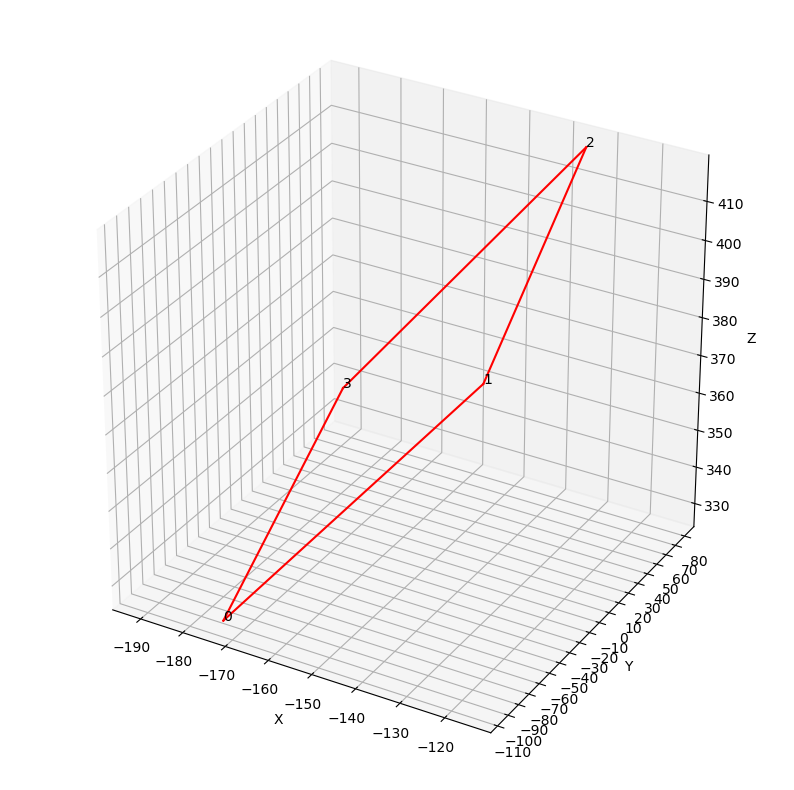

In [8]:
stereo_loc = Stereo_Screen_Location(mtx1, mtx2, dist1, dist2, R1_2, R2_1, T1_2, T2_1)
# uvs1_tl, uvs2_tl = [343,181], [270,170]
# uvs1_tr, uvs2_tr = [382,167], [310,181]
# uvs1_dl, uvs2_dl = [340, 222], [273, 216]
# uvs1_dr, uvs2_dr = [381, 212], [314, 222]

# uvs1_tl, uvs2_tl = [305,142], [378,160]
# uvs1_tr, uvs2_tr = [367,116], [408,178]
# uvs1_dl, uvs2_dl = [288, 200], [391, 213]
# uvs1_dr, uvs2_dr = [352, 184], [423, 225]


uvs1_tl, uvs2_tl = [383, 172], [164,163]
uvs1_tr, uvs2_tr = [452, 164], [228, 179]
uvs1_dl, uvs2_dl = [383, 288], [156, 301]
uvs1_dr, uvs2_dr = [452, 303], [219, 289]

cam1_3d_tl, cam2_3d_tl= stereo_loc.pxl2cam(uvs1_tl, uvs2_tl)
cam1_3d_tr, cam2_3d_tr = stereo_loc.pxl2cam(uvs1_tr, uvs2_tr)
cam1_3d_dl, cam2_3d_dl = stereo_loc.pxl2cam(uvs1_dl, uvs2_dl)
cam1_3d_dr, cam2_3d_dr = stereo_loc.pxl2cam(uvs1_dr, uvs2_dr)
p3ds = np.array([cam1_3d_tl, cam1_3d_tr,cam1_3d_dr, cam1_3d_dl]).reshape(4,3)
print(p3ds)
from mpl_toolkits.mplot3d import Axes3D
 
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection='3d')
# ax.set_xlim3d(-15, 5)
# ax.set_ylim3d(-10, 10)
# ax.set_zlim3d(10, 30)
 
connections = [[0,1], [1,2], [2,3],[3,0]]
for _c in connections:
    print(p3ds[_c[0]],p3ds[_c[1]])
    # print()
    ax.plot(xs = [p3ds[_c[0],0], p3ds[_c[1],0]], ys = [p3ds[_c[0],1], p3ds[_c[1],1]], zs = [p3ds[_c[0],2], p3ds[_c[1],2]], c = 'red')
    ax.text(p3ds[_c[0],0], p3ds[_c[0],1],p3ds[_c[0],2], str(_c[0]))
# 设置坐标轴标签
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
# 设置刻度间隔为10
ax.xaxis.set_major_locator(MultipleLocator(10))
ax.yaxis.set_major_locator(MultipleLocator(10))
ax.zaxis.set_major_locator(MultipleLocator(10))
plt.show()

99.89092773231931 180.36636111272094 99.85603684305265 181.5043235542233
这四个点不围成一个矩形。


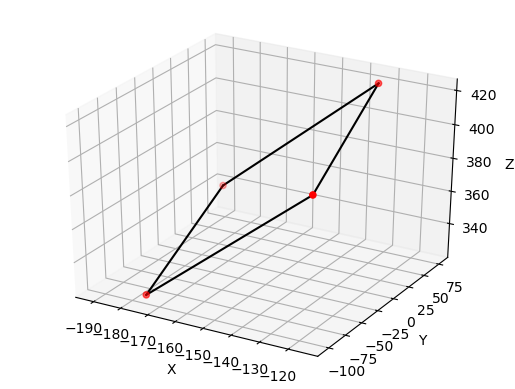

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def is_rectangle(points):
    # 确保有四个点
    if len(points) != 4:
        return False
    
    # 计算向量
    A, B, C, D = points
    AB = B - A
    BC = C - B
    CD = D - C
    DA = A - D
    
    AB_length = np.linalg.norm(AB)
    BC_length = np.linalg.norm(BC)
    CD_length = np.linalg.norm(CD)
    DA_length = np.linalg.norm(DA)
    print(AB_length, BC_length, CD_length, DA_length)
    # 检查向量是否垂直
    def is_orthogonal(v1, v2):
        return np.dot(v1, v2) == 0
    
    if not (is_orthogonal(AB, BC) and is_orthogonal(BC, CD) and is_orthogonal(CD, DA) and is_orthogonal(DA, AB)):
        return False
    
    # 检查向量是否相等
    def vector_length(v):
        return np.linalg.norm(v)
    
    if not (vector_length(AB) == vector_length(CD) and vector_length(BC) == vector_length(DA)):
        return False
    
    # 检查是否封闭
    if not np.allclose(AB + BC + CD + DA, np.zeros(3)):
        return False
    
    return True

def plot_points(points):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    
    # 绘制点
    ax.scatter(points[:, 0], points[:, 1], points[:, 2], c='r', marker='o')
    
    # 绘制边
    for i in range(4):
        ax.plot([points[i, 0], points[(i+1)%4, 0]], 
                [points[i, 1], points[(i+1)%4, 1]], 
                [points[i, 2], points[(i+1)%4, 2]], 'k-')
    
    # 设置坐标轴标签
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    
    plt.show()

# 示例点


# 判断是否为矩形
if is_rectangle(p3ds):
    print("这四个点围成一个矩形。")
else:
    print("这四个点不围成一个矩形。")

# 可视化点
plot_points(p3ds)

步骤3.2 可视化，cam1相机坐标系转换到cam_sup相机坐标系

[-78.57067405 -49.3598999  297.83040171] [ 66.20213174 -87.24717289 388.18578769]
[ 66.20213174 -87.24717289 388.18578769] [107.6486047   55.37707738 399.62805878]
[107.6486047   55.37707738 399.62805878] [-77.21942811 104.34577613 281.75199938]
[-77.21942811 104.34577613 281.75199938] [-78.57067405 -49.3598999  297.83040171]


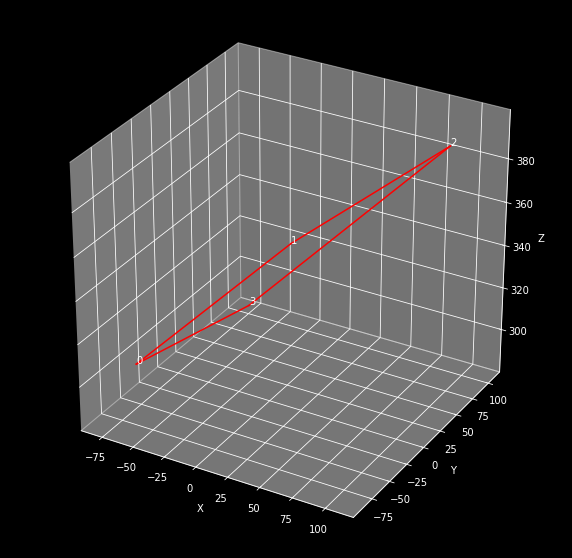

In [7]:
# 将cam1坐标 转换到 cam3的坐标系中
# 相机1的外参
R1 = np.array([[1, 0, 0],
               [0, 1, 0],
               [0, 0, 1]])

T1 = np.array([[0],
               [0],
               [0]])
cam3_points = []
for i in range(4):
    P3 = R3_1.dot(p3ds[i].reshape(3,1)) + T3_1
    cam3_points.append(P3.reshape(3))
    # print(P3.reshape(3))
cam3_points = np.array(cam3_points)
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection='3d')
connections = [[0,1], [1,2], [2,3],[3,0]]
for _c in connections:
    print(cam3_points[_c[0]],cam3_points[_c[1]])
    # print()
    ax.text(cam3_points[_c[0],0], cam3_points[_c[0],1],cam3_points[_c[0],2], str(_c[0]))
    ax.plot(xs = [cam3_points[_c[0],0], cam3_points[_c[1],0]], ys = [cam3_points[_c[0],1], cam3_points[_c[1],1]], zs = [cam3_points[_c[0],2], cam3_points[_c[1],2]], c = 'red')
# 设置坐标轴标签
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.show()

步骤3.3：cam_sup相机坐系(3D)到屏幕平面坐标系(2D) 转换

步骤3.3.1 cam_sup相机坐系(3D)到屏幕平面坐标系(2D)标定仿射变化矩阵

In [ ]:
image_path = './IR_Calibrate_dataset_Filter\Cam1_CamSup\CamSup2Screen\WIN_20240527_18_08_52_Pro.jpg'
image = cv2.imread(image_path)
gray = cv.cvtColor(image.astype(np.uint8), cv.COLOR_BGR2GRAY)
rows = 14 #number of checkerboard rows.
columns = 8 #number of checkerboard columns.
world_scaling = 20. #change this to the real world square size. Or not.

#coordinates of squares in the checkerboard world space
objp = np.zeros((rows*columns,3), dtype=np.float32)
objp[:,:2] = np.mgrid[0:rows,0:columns].T.reshape(-1,2)
objp = world_scaling* objp

#frame dimensions. Frames should be the same size.
width = image.shape[1]
height = image.shape[0]

#Pixel coordinates of checkerboards
imgpoints = [] # 2d points in image plane.

#coordinates of the checkerboard in checkerboard world space.
objpoints = [] # 3d point in real world space
ret, corners = cv.findChessboardCorners(gray, (rows, columns),flags = cv.CALIB_CB_ADAPTIVE_THRESH|cv.CALIB_CB_NORMALIZE_IMAGE|cv.CALIB_CB_FAST_CHECK)
# gray = cv.cvtColor(gray, cv.COLOR_BGR2GRAY)
# 角点坐标亚像素优化
corners = cv.cornerSubPix(gray, corners, (3, 3), (-1, -1),
                            (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 30, 0.001))
objpoints.append(objp)
imgpoints.append(corners)
N_OK = len(objpoints)
K = np.load("Matrix_calibrate\Cam3_Fisher_Intrinsic.npz")['mtx']
D = np.load("Matrix_calibrate\Cam3_Fisher_Intrinsic.npz")['dist']

_, rvec, tvec = cv2.solvePnP(objpoints[0], imgpoints[0], K, D)  # 解算位姿
rvec_matrix = cv2.Rodrigues(rvec)[0]  # 旋转向量->旋转矩阵
distance = np.sqrt(tvec[0] ** 2 + tvec[1] ** 2 + tvec[2] ** 2)  # 计算距离
np.savez("Matrix_calibrate/Cam3_to_Screen_Fisher_Extrinsic.npz", R = rvec_matrix, T=tvec)

步骤3.3.2：cam_sup相机坐标系转换到屏幕坐标系

[ 70.96716751   9.30059563 -49.69514151   1.        ] [244.76625313   3.68438398 -31.77748175   1.        ]
[244.76625313   3.68438398 -31.77748175   1.        ] [259.58996727 151.77258509 -38.1457346    1.        ]
[259.58996727 151.77258509 -38.1457346    1.        ] [ 36.47445336 159.34001254 -63.26723702   1.        ]
[ 36.47445336 159.34001254 -63.26723702   1.        ] [ 70.96716751   9.30059563 -49.69514151   1.        ]


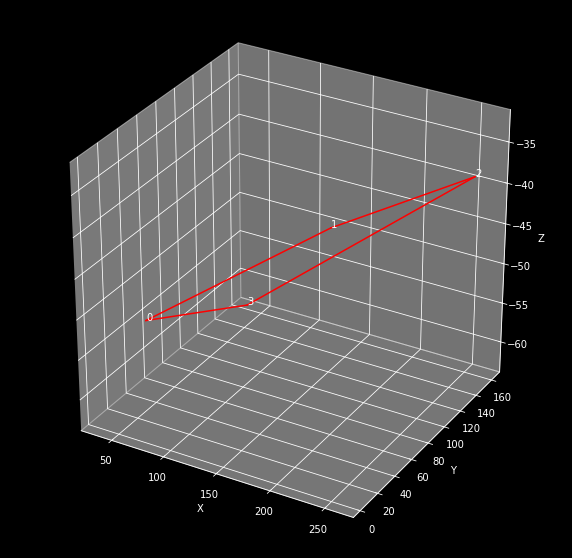

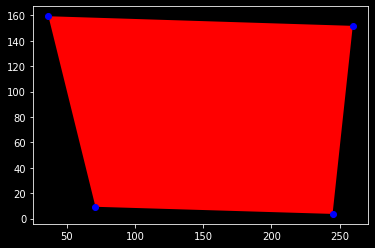

In [8]:
Rs_3, Ts_3 = np.load("Matrix_calibrate\Cam3_to_Screen_Fisher_Extrinsic.npz")['R'], np.load("Matrix_calibrate\Cam3_to_Screen_Fisher_Extrinsic.npz")['T']
Rs_3, Ts_3
T = np.concatenate([np.concatenate([Rs_3,Ts_3],axis=1), np.array([[0,0,0,1]])], axis=0)
screen_points = []
for i in range(4):
    
    ps = np.linalg.inv(T).dot(np.array(list(cam3_points[i]) +[1]).reshape(4,1))
    screen_points.append(ps.reshape(1,4)[0])
screen_points = np.array(screen_points)
# print(screen_points)
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection='3d')
connections = [[0,1], [1,2], [2,3],[3,0]]
for _c in connections:
    print(screen_points[_c[0]],screen_points[_c[1]])
    # print()
    ax.text(screen_points[_c[0],0], screen_points[_c[0],1],screen_points[_c[0],2], str(_c[0]))
    ax.plot(xs = [screen_points[_c[0],0], screen_points[_c[1],0]], ys = [screen_points[_c[0],1], screen_points[_c[1],1]], zs = [screen_points[_c[0],2], screen_points[_c[1],2]], c = 'red')
# 设置坐标轴标签
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.show()

plt.plot(screen_points[:,0], screen_points[:,1], 'bo')
plt.fill(screen_points[:,0], screen_points[:,1], 'r')
plt.show()  # 可以看出，世界坐标系中的box基本是个矩形

In [ ]:
#像素点去畸变 和 图像去畸变可视化
#Stereo Triangulation
frame1 = cv.imread(r'D:\FJX\IR_Localization\Tools\IR_Calibration\Calibration_dataset\20230428_IR_Calibrate_Dataset\Stereo_Vision_Location\chessboard_1thLine\chessboard-L0.png')
frame2 = cv.imread(r'D:\FJX\IR_Localization\Tools\IR_Calibration\Calibration_dataset\20230428_IR_Calibrate_Dataset\Stereo_Vision_Location\chessboard_1thLine\chessboard-R0.png')
undistorted_frame1 = cv2.fisheye.undistortImage(distorted=frame1, K=mtx1, D=dist1, Knew=mtx1)
undistorted_frame2 = cv2.fisheye.undistortImage(distorted=frame2, K=mtx2, D=dist2, Knew=mtx2)

uvs1 = [[217,231]]
uvs2 = [[585,247]]

uvs1 = np.array(uvs1).reshape((-1,1,2))
uvs2 = np.array(uvs2).reshape((-1,1,2))
undistort_uvs1 = cv2.fisheye.undistortPoints(uvs1.astype(np.float32), K=mtx1, D=dist1, P=mtx1)
undistort_uvs2 = cv2.fisheye.undistortPoints(uvs2.astype(np.float32), K=mtx2, D=dist2, P=mtx2)
 

plt.figure(figsize=(20,10))
plt.subplot(1,2,1)
plt.imshow(frame1[:,:,[2,1,0]])
plt.scatter(uvs1[:,:,0], uvs1[:,:,1])
plt.subplot(1,2,2)
plt.imshow(undistorted_frame1[:,:,[2,1,0]])
plt.scatter(undistort_uvs1[:,:,0], undistort_uvs1[:,:,1])
plt.show()
 
plt.figure(figsize=(20,10))
plt.subplot(1,2,1)
plt.imshow(frame2[:,:,[2,1,0]])
plt.scatter(uvs2[:,:,0], uvs2[:,:,1])
plt.subplot(1,2,2)
plt.imshow(undistorted_frame2[:,:,[2,1,0]])
plt.scatter(undistort_uvs2[:,:,0], undistort_uvs2[:,:,1])
plt.show()

In [ ]:
# #评估测量误差
# import pandas as pd
# point_data = pd.read_csv(r"D:\FJX\IR_Localization\Tools\IR_Calibration\Calibration_dataset\20230428_IR_Calibrate_Dataset\Stereo_Vision_Location\chessboard_1thLine\chessboard_1thLine.csv",header=None)
# df = point_data.sort_values(3, ascending=True)
# cam1_point_uvs = df[[1,2]][:11].values
# cam2_point_uvs = df[[1,2]][11:].values
# cam1_point_uvs, cam2_point_uvs
# screen_points = []
# for i in range(1, len(cam1_point_uvs)):
#     print(stereo_loc.pxl2screen(uvs1=cam1_point_uvs[i], uvs2=cam2_point_uvs[i]), stereo_loc.pxl2screen(uvs1=cam1_point_uvs[i-1], uvs2=cam2_point_uvs[i-1]))
#     screen_point = stereo_loc.pxl2screen(uvs1=cam1_point_uvs[i], uvs2=cam2_point_uvs[i]) - stereo_loc.pxl2screen(uvs1=cam1_point_uvs[i-1], uvs2=cam2_point_uvs[i-1])
#     screen_points.append(screen_point)
# error = abs(np.array(screen_points).reshape(-1,2) -[25,0])

### 方法2：直接标定Cam1相机坐标系和Screen坐标系的仿射变换，不依赖辅助相机，只适用于单个机器进行标

方法2：直接标定Cam1相机坐标系和Screen坐标系的仿射变换

比较笨的方法, 首先人为找到屏幕中每个角点（用一个极细笔尖点击角点），人为找到两个图像的像素坐标，然后通过cam1和cam2内外参和三角测量得到cam1的相机坐标系坐标(3D)，最后根据角点的物理位置(角点在屏幕中的物理距离)，相机坐标系和物理坐标进行配对PnP解算仿射矩阵

In [ ]:
stereo_loc = Stereo_Screen_Location(mtx1, mtx2, dist1, dist2, R1_2, R2_1, T1_2, T2_1)
cam1_3d_points = []
cam2_3d_points = []
rows = 11 #number of checkerboard rows.
columns = 8 #number of checkerboard columns.
world_scaling = 25. #change this to the real world square size. Or not.
#coordinates of squares in the checkerboard world space
objp = np.zeros((rows*columns,3), dtype=np.float32)
objp[:,:2] = np.mgrid[0:rows,0:columns].T.reshape(-1,2)
screen_points = world_scaling* objp

point_data = pd.read_csv(r"D:\FJX\IR_Localization\Tools\IR_Calibration\Calibration_dataset\20230407_IR_Calibrate_Dataset\Affine3D_Dataset\chessboard_ALL\chessboard_ALL.csv",header=None)
df = point_data.sort_values(3, ascending=True)
df.shape[0] // 2
cam2_point_uvs = df[[1,2]][:(df.shape[0] // 2)].values
cam1_point_uvs = df[[1,2]][(df.shape[0] // 2):].values
for i in range(len(cam1_point_uvs)):
    cam1_3d, cam2_3d  = stereo_loc.pxl2cam(uvs1=cam1_point_uvs[i], uvs2=cam2_point_uvs[i])
    cam1_3d_points.append(cam1_3d[0])
    cam2_3d_points.append(cam2_3d[0])
cam1_3d_points = np.array(cam1_3d_points)
cam2_3d_points = np.array(cam2_3d_points)

ret, H1, affine_matrix = cv.estimateAffine3D(cam1_3d_points, screen_points)
ret, H2, affine_matrix = cv.estimateAffine3D(cam2_3d_points, screen_points)

np.savez("Cam1_to_Screen_Extrinsic.npz", H = H1)
np.savez("Cam2_to_Screen_Extrinsic.npz", H = H2)
    

评估误差

In [ ]:
H1 = np.load("Cam1_to_Screen_Extrinsic.npz")['H']
H2 = np.load("Cam2_to_Screen_Extrinsic.npz")['H']
stereo_loc = Stereo_Screen_Location(mtx1, mtx2, dist1, dist2, R1_2, R2_1, T1_2, T2_1,H1,H2)
uvs1_tl, uvs2_tl = [[220,231]], [[584,248]]
uvs1_tr, uvs2_tr = [[131,221]], [[475,254]]
uvs1_dl, uvs2_dl = [[409, 213]], [[426, 243]]
uvs1_dr, uvs2_dr = [[263, 215]], [[281, 241]]
screen_tl = stereo_loc.pxl2camleft2screen(uvs1_tl, uvs2_tl)
screen_tr = stereo_loc.pxl2camleft2screen(uvs1_tr, uvs2_tr)
screen_dl = stereo_loc.pxl2camleft2screen(uvs1_dl, uvs2_dl)
screen_dr = stereo_loc.pxl2camleft2screen(uvs1_dr, uvs2_dr)
screen_pts = np.array([screen_tl, screen_tr, screen_dr, screen_dl]).reshape(-1,3) # 每个点都是(x, y)
x = screen_pts[:, 0]  #构造横坐标数据
y = screen_pts[:, 1]  #构造纵坐标数据
plt.plot(x, y, 'bo')
plt.fill(x, y, 'r')
plt.show()  # 可以看出，世界坐标系中的box基本是个矩形
print('pxl2camlet2screen:',screen_pts)

# screen_tl = stereo_loc.pxl2camright2screen(uvs1_tl, uvs2_tl)
# screen_tr = stereo_loc.pxl2camright2screen(uvs1_tr, uvs2_tr)
# screen_dl = stereo_loc.pxl2camright2screen(uvs1_dl, uvs2_dl)
# screen_dr = stereo_loc.pxl2camright2screen(uvs1_dr, uvs2_dr)
# screen_pts = np.array([screen_tl, screen_tr, screen_dr, screen_dl]).reshape(-1,3) # 每个点都是(x, y)
# x = screen_pts[:, 0]  #构造横坐标数据
# y = screen_pts[:, 1]  #构造纵坐标数据
# plt.plot(x, y, 'bo')
# plt.fill(x, y, 'r')
# plt.show()  # 可以看出，世界坐标系中的box基本是个矩形
# print('pxl2camright2screen:',screen_pts)


In [ ]:
errors = []
for i in range(len(cam1_3d_points)):
    cam1_3d_point = np.append(cam1_3d_points[i],1)
    pred_sreen_point = H1 @ cam1_3d_point
    gt_screen_point = screen_points[i]
    error = pred_sreen_point - gt_screen_point
    
    errors.append(error)
errors = np.array(errors)   
np.mean(abs(errors),axis=0), np.std(abs(errors),axis=0)